# 04 - EPO + PLS回帰
**近赤外研究会 スペクトル分析チャレンジ**

## このノートブックの目的
- EPO（External Parameter Orthogonalization）で樹種間干渉を除去する
- SNV → EPO → PLS3 のパイプラインでLB 19.59超えを狙う
- GroupKFold / LOSO で 03_baseline との比較評価を行う

## EPOの原理
train 13樹種のSNVスペクトルから「樹種固有の平均的なスペクトル変動方向」を推定し、
その方向成分をtrain/testのスペクトルから除去する。

```
D = 樹種平均スペクトル行列の上位k方向（SVDで取得）
X_epo = X - (X @ D.T) @ D  ← Dに射影した成分を引く
```

**制約**: DはtrainのみからFitする（testは一切使わない）

## 0. ライブラリのインポート

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import japanize_matplotlib
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error
from pathlib import Path

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

Path('../submissions').mkdir(parents=True, exist_ok=True)

print('ライブラリ読み込み完了')

ライブラリ読み込み完了


## 1. データの読み込み

In [11]:
train = pd.read_csv('../data/train_near.csv', encoding='cp932')
test  = pd.read_csv('../data/test_near.csv',  encoding='cp932')

META_COLS = ['sample number', 'species number', '樹種', '含水率']
SPEC_COLS = [c for c in train.columns if c not in META_COLS]

X_train = train[SPEC_COLS].values
X_test  = test[SPEC_COLS].values
y_train = train['含水率'].values
groups  = train['樹種'].values

y_min, y_max = y_train.min(), y_train.max()

print(f'Train : {X_train.shape}')
print(f'Test  : {X_test.shape}')
print(f'含水率範囲 : {y_min:.2f} – {y_max:.2f} %')

Train : (1322, 1555)
Test  : (550, 1555)
含水率範囲 : 0.84 – 298.58 %


## 2. 前処理（SNV）

In [12]:
def snv(X):
    mean = X.mean(axis=1, keepdims=True)
    std  = X.std(axis=1, keepdims=True)
    return (X - mean) / std

X_train_snv = snv(X_train)
X_test_snv  = snv(X_test)

print('SNV前処理完了')

SNV前処理完了


## 3. EPO（External Parameter Orthogonalization）

### 手順
1. train 13樹種ごとのSNVスペクトル平均を計算
2. 全体平均を引いて「樹種間差分行列」を作る
3. SVDで上位k方向（最も大きな樹種間変動方向）を取得
4. その方向をtrain/testスペクトルから射影除去

### パラメータ: `N_EPO_COMPONENTS`
- 除去する干渉方向数。大きすぎると水分信号まで消える。
- 文献では2〜5が多い。ここでは2を起点にLOSOで確認する。
- ⚠️ CVでチューニングしない（#4の失敗と同じ罠）→ LOSOで傾向確認後、LBで1回だけ確認

In [13]:
def fit_epo(X_train_snv, groups, n_components=2):
    """
    trainデータのみからEPO射影行列を推定する。
    戻り値 D: shape (n_components, n_wavelengths) — 干渉方向（正規直交）
    """
    species_list = np.unique(groups)
    # 各樹種のSNVスペクトル平均
    species_means = np.array([
        X_train_snv[groups == sp].mean(axis=0) for sp in species_list
    ])  # (n_species, n_wavelengths)

    # 全体平均を引いて樹種間差分行列を作る
    grand_mean = species_means.mean(axis=0)
    D_matrix   = species_means - grand_mean  # (n_species, n_wavelengths)

    # SVD → 上位k方向が最大の樹種間変動方向
    _, _, Vt = np.linalg.svd(D_matrix, full_matrices=False)
    D = Vt[:n_components]  # (n_components, n_wavelengths) 正規直交

    return D


def apply_epo(X, D):
    """
    EPO射影を適用する。
    X_epo = X - (X @ D.T) @ D
    """
    return X - (X @ D.T) @ D


# n_componentsの値をここで設定
N_EPO_COMPONENTS = 2

D_epo = fit_epo(X_train_snv, groups, n_components=N_EPO_COMPONENTS)

X_train_epo = apply_epo(X_train_snv, D_epo)
X_test_epo  = apply_epo(X_test_snv,  D_epo)

print(f'EPO完了 (n_components={N_EPO_COMPONENTS})')
print(f'Train: {X_train_epo.shape}, Test: {X_test_epo.shape}')

EPO完了 (n_components=2)
Train: (1322, 1555), Test: (550, 1555)


## 4. EPOの効果を可視化

樹種ごとの平均スペクトルを補正前後で比較する。
補正後に樹種間の差が減っていれば干渉除去が効いている。

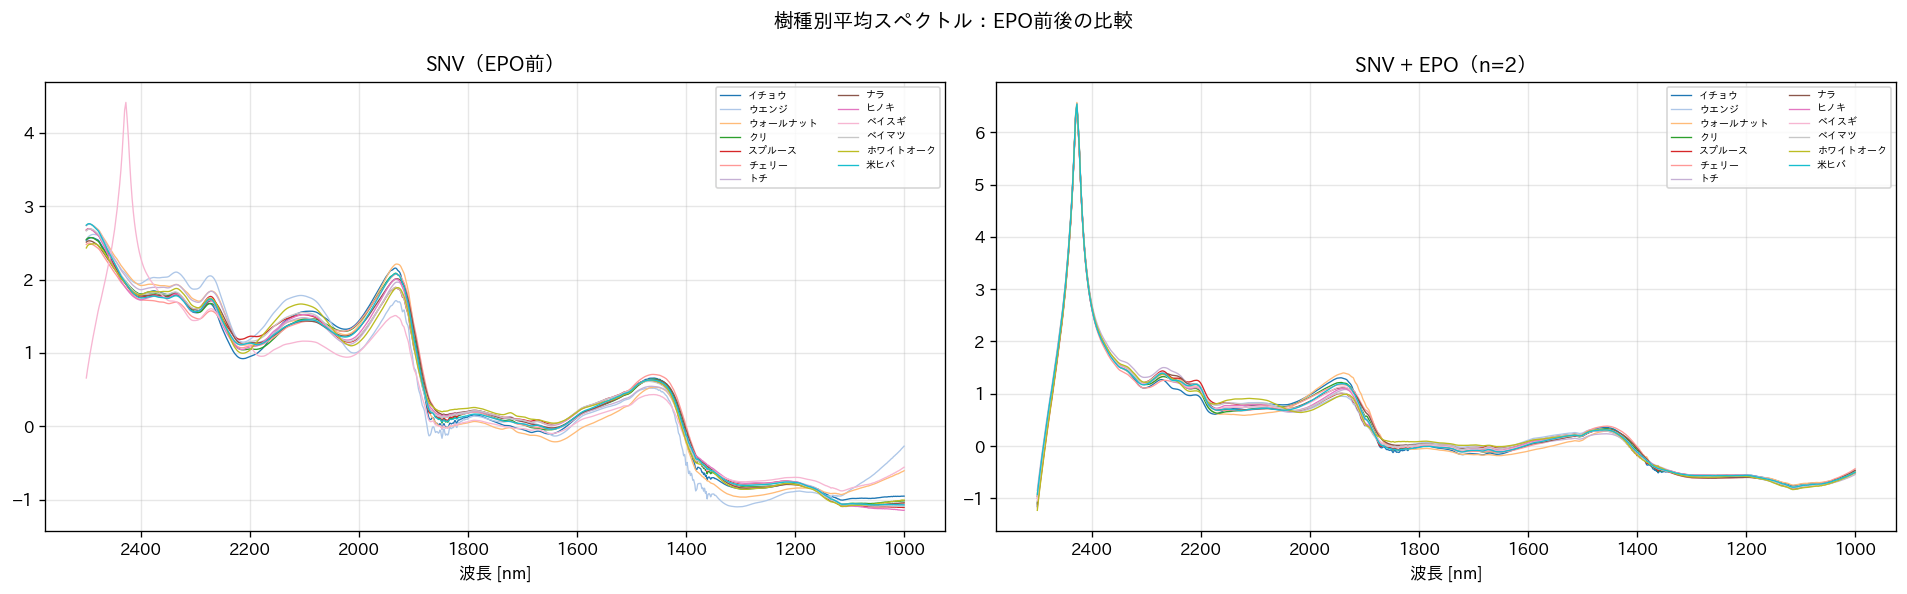

In [14]:
WAVENUMS    = np.array([float(c) for c in SPEC_COLS])
WAVELENGTHS = 10_000 / WAVENUMS * 1000  # nm変換

species_list = np.unique(groups)
cmap = plt.cm.tab20

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for sp_idx, sp in enumerate(species_list):
    mask  = groups == sp
    color = cmap(sp_idx / len(species_list))

    mean_before = X_train_snv[mask].mean(axis=0)
    mean_after  = X_train_epo[mask].mean(axis=0)

    axes[0].plot(WAVELENGTHS, mean_before, color=color, linewidth=0.8, label=sp)
    axes[1].plot(WAVELENGTHS, mean_after,  color=color, linewidth=0.8, label=sp)

for ax, title in zip(axes, ['SNV（EPO前）', f'SNV + EPO（n={N_EPO_COMPONENTS}）']):
    ax.set_title(title)
    ax.set_xlabel('波長 [nm]')
    ax.invert_xaxis()
    ax.legend(fontsize=6, ncol=2)

plt.suptitle('樹種別平均スペクトル：EPO前後の比較', fontsize=12)
plt.tight_layout()
plt.show()

## 5. GroupKFold CV（EPOあり vs なし）

In [15]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


def groupkfold_cv(X, y, groups, n_components=3, n_splits=5, label=''):
    gkf = GroupKFold(n_splits=n_splits)
    oof = np.zeros(len(y))
    for fold, (tr_idx, val_idx) in enumerate(gkf.split(X, y, groups)):
        pls = PLSRegression(n_components=n_components)
        pls.fit(X[tr_idx], y[tr_idx])
        oof[val_idx] = pls.predict(X[val_idx]).ravel()
    cv = rmse(y, oof)
    print(f'{label:<25} GroupKFold CV RMSE: {cv:.4f}')
    return cv, oof


cv_baseline, _ = groupkfold_cv(X_train_snv, y_train, groups, label='SNV + PLS3（ベースライン）')
cv_epo,      _ = groupkfold_cv(X_train_epo, y_train, groups, label=f'SNV + EPO(n={N_EPO_COMPONENTS}) + PLS3')

SNV + PLS3（ベースライン）        GroupKFold CV RMSE: 27.8477
SNV + EPO(n=2) + PLS3     GroupKFold CV RMSE: 27.7960


## 6. LOSO CV（EPOあり vs なし）

⚠️ EPOのn_componentsはここで傾向を確認するが、  
CVスコアで最適値を選ばない（#4の失敗と同じ罠）。  
最終確認はLBで1回だけ行う。

In [16]:
def loso_cv(X_snv, y, groups, n_pls=3, n_epo=0, label=''):
    """
    LOSO CV。n_epo>0のときはfold内でEPOをtrainデータだけからFitする。
    """
    species_list = np.unique(groups)
    scores = {}

    for sp in species_list:
        val_mask = groups == sp
        tr_mask  = ~val_mask

        X_tr = X_snv[tr_mask]
        X_val = X_snv[val_mask]

        if n_epo > 0:
            D = fit_epo(X_tr, groups[tr_mask], n_components=n_epo)
            X_tr  = apply_epo(X_tr,  D)
            X_val = apply_epo(X_val, D)

        pls = PLSRegression(n_components=n_pls)
        pls.fit(X_tr, y[tr_mask])
        scores[sp] = rmse(y[val_mask], pls.predict(X_val).ravel())

    s = pd.Series(scores).sort_values()
    print(f'\n{label}')
    print(s.round(2).to_string())
    print(f'mean: {s.mean():.4f}  median: {s.median():.4f}')
    return s


loso_base = loso_cv(X_train_snv, y_train, groups,
                    n_pls=3, n_epo=0, label='SNV + PLS3（ベースライン）')

loso_epo  = loso_cv(X_train_snv, y_train, groups,
                    n_pls=3, n_epo=N_EPO_COMPONENTS,
                    label=f'SNV + EPO(n={N_EPO_COMPONENTS}) + PLS3')


SNV + PLS3（ベースライン）
スプルース       5.05
ベイマツ        6.51
クリ         10.83
トチ         12.70
ウォールナット    14.19
米ヒバ        14.41
ヒノキ        15.07
ホワイトオーク    15.55
イチョウ       18.20
ナラ         23.21
ウエンジ       34.62
チェリー       35.90
ベイスギ       71.33
mean: 21.3526  median: 15.0709

SNV + EPO(n=2) + PLS3
ベイマツ         7.18
ウォールナット      7.73
スプルース        9.13
クリ          10.63
ヒノキ         11.44
米ヒバ         15.16
イチョウ        17.24
トチ          17.98
ホワイトオーク     20.60
ナラ          20.73
チェリー        32.95
ウエンジ        49.88
ベイスギ       249.43
mean: 36.1603  median: 17.2376


## 6b. n_componentsの感度確認（参考）

LOSOの mean/median を複数のn_componentsで確認する。  
あくまで傾向把握用。この結果でn_componentsを最適化しない。

In [20]:
print('n_epo  LOSO_mean  LOSO_median')
print('-----  ---------  -----------')

for n in [0, 1, 2, 3, 5, 8]:
    species_all = np.unique(groups)
    scores = {}
    for sp in species_all:
        val_mask = groups == sp
        tr_mask  = ~val_mask
        X_tr  = X_train_snv[tr_mask]
        X_val = X_train_snv[val_mask]
        if n > 0:
            D = fit_epo(X_tr, groups[tr_mask], n_components=n)
            X_tr  = apply_epo(X_tr,  D)
            X_val = apply_epo(X_val, D)
        pls = PLSRegression(n_components=3)
        pls.fit(X_tr, y_train[tr_mask])
        scores[sp] = rmse(y_train[val_mask], pls.predict(X_val).ravel())
    s = pd.Series(scores)
    print(f'  {n:2d}     {s.mean():6.2f}       {s.median():6.2f}')


n_epo  LOSO_mean  LOSO_median
-----  ---------  -----------
   0      21.35        15.07
   1      24.82        15.77
   2      36.16        17.24
   3      70.92        21.88
   5      85.67        24.87
   8      94.13        24.37


## 7. 最終モデル・提出CSV生成

N_EPO_COMPONENTSはセル3で設定した値を使う。

In [18]:
pls_final = PLSRegression(n_components=3)
pls_final.fit(X_train_epo, y_train)

y_pred         = pls_final.predict(X_test_epo).ravel()
y_pred_clipped = np.clip(y_pred, y_min, y_max)

print(f'予測値（clip前）: min={y_pred.min():.2f}, max={y_pred.max():.2f}')
print(f'予測値（clip後）: min={y_pred_clipped.min():.2f}, max={y_pred_clipped.max():.2f}')

fname = f'../submissions/submission_epo{N_EPO_COMPONENTS}_pls3.csv'
submission = pd.DataFrame({
    'sample number': test['sample number'],
    '含水率': y_pred_clipped
})
submission.to_csv(fname, index=False, header=False)
print(f'\n提出CSV保存完了: {fname}')
print(submission.head())

予測値（clip前）: min=-18.30, max=179.74
予測値（clip後）: min=0.84, max=179.74

提出CSV保存完了: ../submissions/submission_epo2_pls3.csv
   sample number         含水率
0             95  171.686169
1             96  151.196227
2             97  140.768188
3             98  137.133265
4             99  132.654385


## 8. まとめ

| 項目 | ベースライン | EPO+PLS3 |
|------|------------|----------|
| GroupKFold CV | （実行後記入） | （実行後記入） |
| LOSO mean | 21.35 | （実行後記入） |
| LOSO median | 15.07 | （実行後記入） |
| LB | 19.59 | （提出後記入） |

### 判断基準
- LOSOのmean/medianがベースラインより**改善している**場合 → LBに提出する
- LOSOが悪化 or 微差 → 提出せずにベースラインを保持
- ⚠️ GroupKFold CVが改善しても、LOSOが悪化していれば提出しない（#4の教訓）

### 次のステップ
- コードの3分割整備（Preprocessing / Learning / Predicting）
- 賞与資料の作成